# MLP Classification: From Mathematics to Deployment

**Author:** Manuel Eugenio Morocho Cayamcela, PhD

This notebook connects three views of the same neural network:

1. The mathematical forward pass.
2. A reproducible scikit-learn pipeline.
3. A deployable model whose parameters can be inspected in Excel.

The example uses the Palmer Penguins dataset, but the ideas apply to many classification problems.

## Learning goals

- Understand the matrix operations inside an MLP.
- Train and evaluate a reproducible classifier.
- Save preprocessing and the model together in a pipeline.
- Inspect weights, biases, scaling parameters, and predictions.
- Connect the Python implementation to an Excel or mathematical implementation.
- Evaluate a model using evidence rather than only a single accuracy number.

## Part 1: Load and understand the data

The Palmer Penguins dataset contains measurements of three penguin species. Before modeling, inspect the variables, missing values, class balance, and units.

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

penguins = sns.load_dataset("penguins")
penguins.head()

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 344 entries, 0 to 343
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   species            344 non-null    object 
 1   island             344 non-null    object 
 2   bill_length_mm     342 non-null    float64
 3   bill_depth_mm      342 non-null    float64
 4   flipper_length_mm  342 non-null    float64
 5   body_mass_g        342 non-null    float64
 6   sex                333 non-null    object 
dtypes: float64(4), object(3)
memory usage: 18.9+ KB
None

Missing values:
species               0
island                0
bill_length_mm        2
bill_depth_mm         2
flipper_length_mm     2
body_mass_g           2
sex                  11
dtype: int64

Class counts:
species
Adelie       152
Gentoo       124
Chinstrap     68
Name: count, dtype: int64


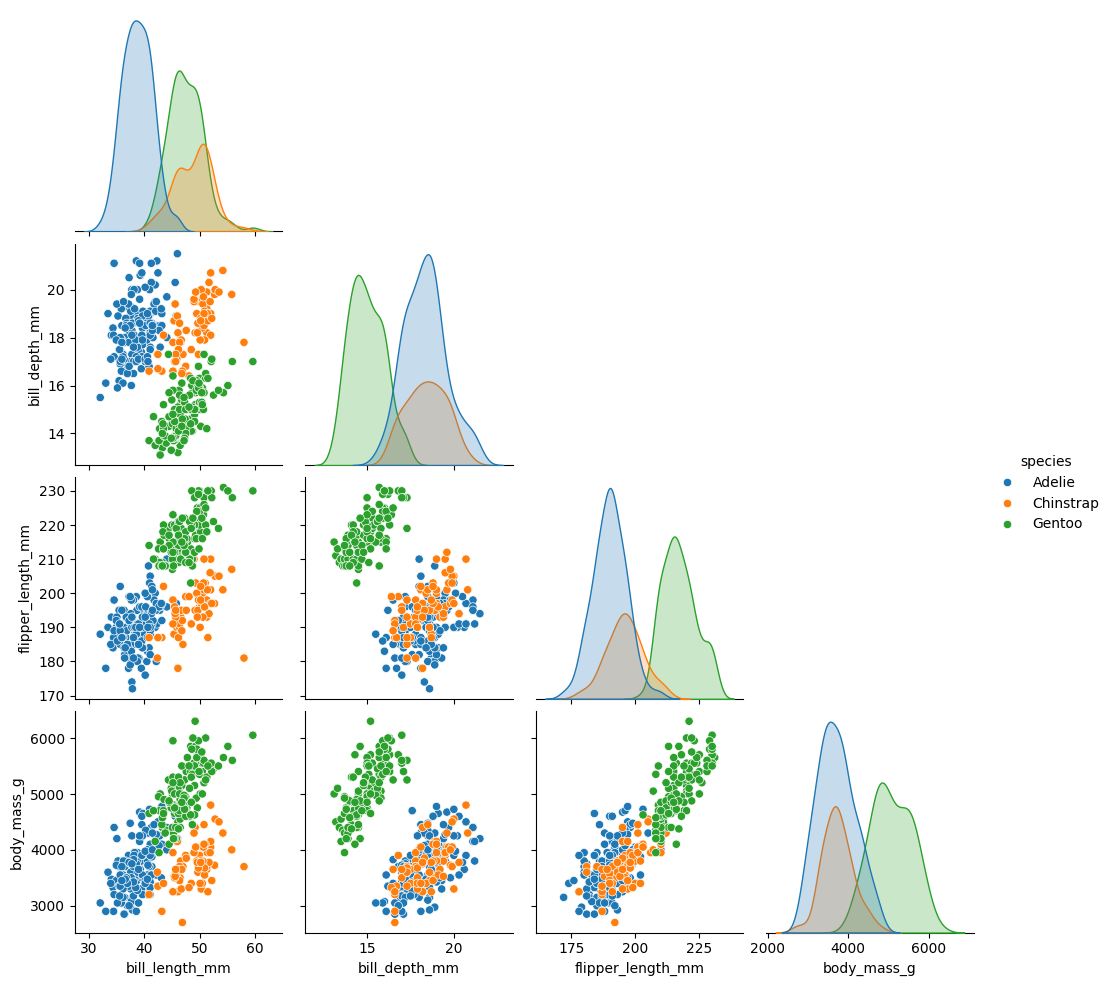

In [2]:
print(penguins.info())
print("\nMissing values:")
print(penguins.isna().sum())
print("\nClass counts:")
print(penguins["species"].value_counts())

sns.pairplot(penguins, hue="species", corner=True)
plt.show()

## Part 2: Prepare features without losing reproducibility

We remove incomplete rows and encode the two categorical variables. The pipeline will standardize numeric columns during training. Keeping preprocessing inside the pipeline prevents applying a different transformation during prediction.

In [3]:
penguins = penguins.dropna().copy()

X = penguins.drop(columns=["species"])
y = penguins["species"]

X["sex"] = X["sex"].map({"Male": 0, "Female": 1})
X["island"] = X["island"].map({"Biscoe": 0, "Dream": 1, "Torgersen": 2})

print(X.dtypes)
X.head()

island                 int64
bill_length_mm       float64
bill_depth_mm        float64
flipper_length_mm    float64
body_mass_g          float64
sex                    int64
dtype: object


,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,2,39.1,18.7,181.0,3750.0,0
1,2,39.5,17.4,186.0,3800.0,1
2,2,40.3,18.0,195.0,3250.0,1
4,2,36.7,19.3,193.0,3450.0,1
5,2,39.3,20.6,190.0,3650.0,0


## Part 3: Train and evaluate an MLP pipeline

An MLP applies affine transformations and nonlinear activation functions. Here, `StandardScaler` and `MLPClassifier` are stored as one object.

Accuracy: 1.0
              precision    recall  f1-score   support

      Adelie       1.00      1.00      1.00        29
   Chinstrap       1.00      1.00      1.00        14
      Gentoo       1.00      1.00      1.00        24

    accuracy                           1.00        67
   macro avg       1.00      1.00      1.00        67
weighted avg       1.00      1.00      1.00        67



/Users/eugenio/Documents/ArtificialIntelligence/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/eugenio/Documents/ArtificialIntelligence/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/eugenio/Documents/ArtificialIntelligence/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/eugenio/Documents/ArtificialIntelligence/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/eugenio/Documents/ArtificialIntelligence/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/eugenio/Documents/ArtificialIntelligence/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: Runtim

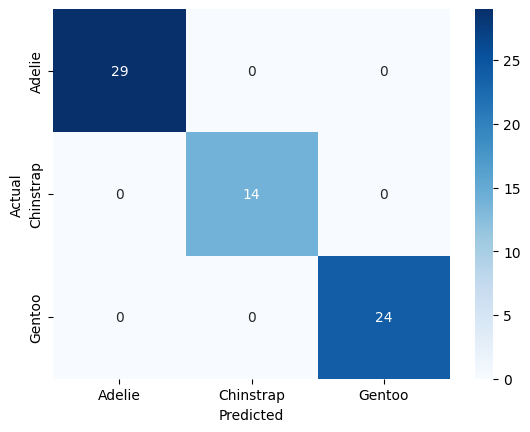

In [4]:
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

model_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("classifier", MLPClassifier(
        hidden_layer_sizes=(20, 10),
        activation="relu",
        max_iter=1000,
        random_state=42
    ))
])

model_pipeline.fit(X_train, y_train)
y_pred = model_pipeline.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

conf = confusion_matrix(y_test, y_pred)
sns.heatmap(
    conf, annot=True, cmap="Blues",
    xticklabels=model_pipeline.classes_,
    yticklabels=model_pipeline.classes_
)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

## Part 4: Backpropagation and gradient descent

Training the MLP has four main steps:

1. **Forward pass:** compute the prediction from the input.
2. **Loss:** measure the difference between the prediction and the target.
3. **Backpropagation:** use the chain rule to calculate the gradient of the loss with respect to each weight.
4. **Gradient descent:** update the weights using the learning rate:

$$
W^{(l)} \leftarrow W^{(l)} - \eta \frac{\partial L}{\partial W^{(l)}}
$$

Here, $\eta$ is the learning rate. `MLPClassifier` performs these calculations internally.

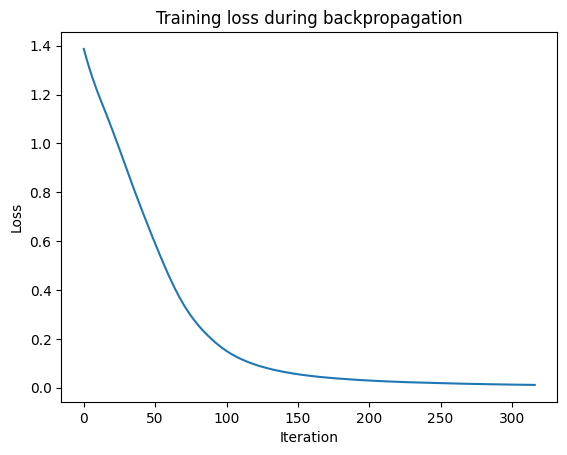

Training iterations: 317
Final loss: 0.011396170778149053


In [5]:
classifier = model_pipeline.named_steps["classifier"]

plt.plot(classifier.loss_curve_)
plt.xlabel("Iteration")
plt.ylabel("Loss")
plt.title("Training loss during backpropagation")
plt.show()

print("Training iterations:", classifier.n_iter_)
print("Final loss:", classifier.loss_)

## Part 5: The mathematical forward pass

For one standardized input vector $x$, each hidden layer computes

$$z^{(l)} = W^{(l)}a^{(l-1)} + b^{(l)}, \qquad a^{(l)} = \operatorname{ReLU}(z^{(l)})$$

The output layer produces class scores and probabilities. In a multiclass classifier, the probabilities are obtained with softmax:

$$p_k = \frac{e^{z_k}}{\sum_j e^{z_j}}$$

The following code exposes the learned parameters.

In [6]:
classifier = model_pipeline.named_steps["classifier"]
scaler = model_pipeline.named_steps["scaler"]

print("Classes:", classifier.classes_)
print("Weight matrix shapes:", [w.shape for w in classifier.coefs_])
print("Bias vector shapes:", [b.shape for b in classifier.intercepts_])
print("Scaler means:", scaler.mean_)
print("Scaler scales:", scaler.scale_)

Classes: ['Adelie' 'Chinstrap' 'Gentoo']
Weight matrix shapes: [(6, 20), (20, 10), (10, 3)]
Bias vector shapes: [(20,), (10,), (3,)]
Scaler means: [6.65413534e-01 4.39842105e+01 1.72259398e+01 2.01300752e+02
 4.22443609e+03 4.77443609e-01]
Scaler scales: [7.18241913e-01 5.47311738e+00 1.97054534e+00 1.40147532e+01
 8.08913955e+02 4.99490950e-01]


## Part 6: Save, reload, and predict

The complete pipeline includes preprocessing and the classifier. New observations must use the original feature scale.

In [15]:
import os
import joblib

os.makedirs("models", exist_ok=True)
joblib.dump(model_pipeline, "models/trained_mlp_penguins.joblib")

loaded_pipeline = joblib.load("models/trained_mlp_penguins.joblib")
print(loaded_pipeline)

Pipeline(steps=[('scaler', StandardScaler()),
                ('classifier',
                 MLPClassifier(hidden_layer_sizes=(20, 10), max_iter=1000,
                               random_state=42))])


In [16]:
new_penguin = pd.DataFrame({
    "island": [0],
    "bill_length_mm": [50.0],
    "bill_depth_mm": [15.0],
    "flipper_length_mm": [200.0],
    "body_mass_g": [4000.0],
    "sex": [0]
})

prediction = loaded_pipeline.predict(new_penguin)
probabilities = loaded_pipeline.predict_proba(new_penguin)[0]

print("Predicted species:", prediction[0])
print(dict(zip(loaded_pipeline.classes_, probabilities)))

Predicted species: Gentoo
{np.str_('Adelie'): np.float64(0.016456528606376395), np.str_('Chinstrap'): np.float64(0.3152891793872644), np.str_('Gentoo'): np.float64(0.6682542920063591)}


## Part 7: Export parameters for Excel

Exporting parameters is useful for learning and auditing. It is not the same as exporting a production-ready model: Excel must still reproduce scaling, matrix multiplication, ReLU, and softmax correctly.

In [17]:
os.makedirs("weights_and_biases", exist_ok=True)

pd.DataFrame({"feature": X.columns, "mean": scaler.mean_, "scale": scaler.scale_}).to_excel(
    "weights_and_biases/scaler_parameters.xlsx", index=False
)

for layer_index, weights in enumerate(classifier.coefs_, start=1):
    pd.DataFrame(weights).to_excel(
        f"weights_and_biases/layer_{layer_index}_weights.xlsx",
        index=False
    )

for layer_index, biases in enumerate(classifier.intercepts_, start=1):
    pd.DataFrame(biases, columns=["bias"]).to_excel(
        f"weights_and_biases/layer_{layer_index}_biases.xlsx",
        index=False
    )

print("Export completed.")

Export completed.


### Excel implementation guide

1. Standardize each input feature with `(value - mean) / scale`.
2. Compute each neuron as a weighted sum plus its bias.
3. Apply ReLU to hidden-layer values: `MAX(0, value)`.
4. Apply softmax to the final class scores.
5. Compare the Excel probabilities with `predict_proba`.

For an MLP with several hidden layers, repeat steps 2 and 3 for each hidden layer.

## Part 8: Joint Individual Investigation

All students will complete the same investigation. The mathematical **forward pass of the MLP must be implemented outside Python**, preferably in Excel or Google Sheets.

### Objective

Reproduce and analyze the model predictions, and investigate how model performance changes after hyperparameter optimization.

### Activities

1. Use different training and test sets from in this notebook.
2. Perform hyperparameter optimization using `GridSearchCV` or `RandomizedSearchCV`. Explore, at minimum:

   - `hidden_layer_sizes`
   - `activation`

3. Record the best hyperparameters, the cross-validation score, and the performance on the test set.
4. Compare the optimized model with the baseline model using `hidden_layer_sizes=(20, 10)`.
5. Export the parameters of the best model to Excel:
   - `StandardScaler` means and scales;
   - weight matrices;
   - bias vectors;
   - model classes.
6. Implement the forward pass of at least one observation outside Python:
   - standardize the input features;
   - perform matrix multiplication and add the biases;
   - apply ReLU to the hidden layers;
   - calculate the output scores;
   - apply the softmax function;
   - obtain the predicted class and probabilities.
7. Compare the probabilities calculated in Excel or Google Sheets with `predict_proba`.

### Required evidence

The submission must include:

- a spreadsheet containing the complete forward-pass calculations;
- the `GridSearchCV` or `RandomizedSearchCV` configuration;
- a comparison table between the baseline and optimized models;
- accuracy, macro F1-score, number of training iterations, and number of parameters;
- at least one chart or table created by the student;
- one limitation of the model and one proposed improvement;
- a brief explanation of why a large weight does not prove causality.

Hyperparameter optimization may be performed in Python. However, the mathematical reproduction of the prediction must be implemented outside Python.

## Part 9: Discussion questions

1. Why is accuracy alone insufficient if the classes are imbalanced?
2. What information is lost when categorical variables are replaced by integer codes?
3. Why must the same scaler parameters be used at inference time?
4. What does a large weight mean, and what does it not prove about causality?
5. When is a transparent Excel implementation useful, and when is it a poor deployment choice?
6. How could you make the experiment more statistically reliable?

## References

- [Scikit-learn MLPClassifier documentation](https://scikit-learn.org/stable/modules/generated/sklearn.neural_network.MLPClassifier.html)
- [Scikit-learn Pipeline documentation](https://scikit-learn.org/stable/modules/compose.html#pipeline)
- [Palmer Penguins dataset](https://allisonhorst.github.io/palmerpenguins/)
- [ONNX documentation](https://onnx.ai/onnx/)